In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph

print(jax.devices())
print(jax.default_backend())

[cuda(id=0)]
gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0

# CAMELS

In [4]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
# CODE = "IllustrisTNG"
CODE = "SIMBA"
# CODE = "Astrid"
SIMSET = "CV"

i_snapshots = range(1, 33+4, 8)

train_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE, SIMSET, "CV_0"),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

vali_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE, SIMSET, "CV_1"),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.42s/it]

Found 368 duplicate gas particle IDs


finding unique gas particle indices:  40%|████      | 2/5 [00:07<00:11,  3.95s/it]

Found 4088 duplicate gas particle IDs


...

finding unique gas particle indices:  80%|████████  | 4/5 [00:18<00:05,  5.03s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:23<00:00,  4.77s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [00:56<00:00, 11.35s/it]


In [5]:
# latent_init = cic_read(cic_paint(jnp.zeros(mesh_shape), gas_poss[0]), gas_poss[0])
# latent_init = jnp.expand_dims(latent_init, axis=-1)

# latent_init = jnp.ones((parts_per_dim**3,1)))

latent_init = None

edges = graph.get_edges(gas_poss, scales, k=4)

def solve_ode_diffrax(dm_model, gas_model):
    res = diffeqsolve(
            # terms=ODETerm(hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, integrator_type="diffrax", architecture=architecture, precomputed_edges=edges)),
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, dm_model, gas_model)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.02,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )

    res = res.ys

    return res

In [6]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

In [92]:
def compare_sims(hydro_dict, dm_model=None, gas_model=None):
    scales = hydro_dict["scales"]
    dm_poss = hydro_dict["dm_poss"]
    dm_vels = hydro_dict["dm_vels"]
    gas_poss = hydro_dict["gas_poss"]
    gas_vels = hydro_dict["gas_vels"]

    og_ode = hpm.get_hpm_network_ode_fn(
        mesh_per_dim, cosmo, dm_model=None, gas_model=None, integrator_type="diffrax"
    )
    
    og_res = diffeqsolve(
            terms=ODETerm(og_ode),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )
    
    og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

    nn_ode = hpm.get_hpm_network_ode_fn(
        mesh_per_dim, cosmo, dm_model=dm_model, gas_model=gas_model, integrator_type="diffrax"
    )
    
    nn_res = diffeqsolve(
            terms=ODETerm(nn_ode),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.01,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
    )
    
    nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys

    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([dm_poss, og_dm_poss, nn_dm_poss], axis=0), 
        title="dark matter",
        col_titles=["CAMELS", "gravity", "gravity + 2x network"],
        include_pk=True,
        include_reference=True,
    )

    plotting.compare_particle_evolution(
        mesh_shape, 
        scales, 
        jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
        title="gas",
        col_titles=["CAMELS", "gravity", "gravity + 2x network"],
        include_pk=True,
        include_reference=True,
    )

# loss

### CAMELS ground truth

In [7]:
gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)

# per-particle reference
ref_dm_poss = jnp.stack(dm_poss, axis=0)
ref_dm_vels = jnp.stack(dm_vels, axis=0)

ref_gas_poss = jnp.stack(gas_poss, axis=0)
ref_gas_vels = jnp.stack(gas_vels, axis=0)

# field-level reference
ref_rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
ref_rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum reference
_, ref_cls_dm = vpower_spectrum(ref_rhos_dm)
_, ref_cls_gas = vpower_spectrum(ref_rhos_gas)

# cross correlation reference
# vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

### particle-level

In [8]:
def dm_loss_fn(dm_poss, dm_vels):
    delta_poss = ((dm_poss - ref_dm_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_poss**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)

    # vel_disp = jnp.std(dm_vels, axis=0)
    # vel_loss = jnp.sum(((dm_vels - ref_dm_vels) / (vel_disp + 1e-5))**2, axis=-1)
    # vel_loss = jnp.mean(vel_loss)

    res_rhos = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
    _, res_cls = vpower_spectrum(res_rhos)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls_dm - 1)**2, axis=-1))

    # _, res_cross = vcross_correlation(res_rho)
    # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
    return pos_loss + 0.1 * cl_loss


In [9]:
def gas_loss_fn(gas_poss, gas_vels):
    delta_poss = ((gas_poss - ref_gas_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_poss**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)

    # vel_disp = jnp.std(dm_vels, axis=0)
    # vel_loss = jnp.sum(((dm_vels - ref_dm_vels) / (vel_disp + 1e-5))**2, axis=-1)
    # vel_loss = jnp.mean(vel_loss)

    res_rhos = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    _, res_cls = vpower_spectrum(res_rhos)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls_gas - 1)**2, axis=-1))

    # _, res_cross = vcross_correlation(res_rho)
    # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

    # return pos_loss + 0.01 * vel_loss + 0.1 * cl_loss
    return pos_loss + 0.1 * cl_loss


### field-level

In [79]:
def field_loss_fn(model, architecture):
    pass

# architecture

In [108]:
dm_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))

### MLP

In [109]:
with_latent = False

gas_model = MLP(
    d_in=5 + with_latent, 
    # d_in=3 + with_latent, 
    d_out=1 + with_latent, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)
architecture = "mlp"

### MLP + CNN

In [110]:
# with_latent = False

# mlp = MLP(
#     d_in=5 + with_latent,
#     d_out=8, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )

# cnn = CNN(
#     d_in=4 + with_latent,
#     d_out=8,
#     d_hidden=8,
#     n_hidden=2,
#     kernel_size=(3, 3, 3),
#     strides=1,
#     rngs=nnx.Rngs(0)
# )

# gas_model = HybridNet(
#     mlp,
#     cnn,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0)
# )

# architecture = "mlp+cnn"

### GNN

on the fly

In [111]:
# with_latent = False

# gas_model = AttentionGNN(
#     d_node=5 + with_latent,
#     d_edge=1,
#     d_query=16,
#     n_hidden=4,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

# training

In [112]:
@nnx.jit
def dm_train_step(dm_model, optimizer):
    def loss_fn(dm_model):
        dm_poss, dm_vels, gas_poss, gas_vels, _ = solve_ode_diffrax(dm_model, None)
        return dm_loss_fn(dm_poss, dm_vels)
    
    loss, grads = nnx.value_and_grad(loss_fn)(dm_model)
    optimizer.update(grads)

    return loss


@nnx.jit
def gas_train_step(gas_model, optimizer):
    def loss_fn(gas_model):
        dm_poss, dm_vels, gas_poss, gas_vels, _ = solve_ode_diffrax(None, gas_model)
        return gas_loss_fn(gas_poss, gas_vels)
    
    loss, grads = nnx.value_and_grad(loss_fn)(gas_model)
    optimizer.update(grads)

    return loss


@nnx.jit
def combined_train_step(dm_model, gas_model, dm_optimizer, gas_optimizer):
    def combined_loss_fn(dm_model, gas_model):
        dm_poss, dm_vels, gas_poss, gas_vels, _ = solve_ode_diffrax(dm_model, gas_model)
        
        dm_loss = dm_loss_fn(dm_poss, dm_vels)
        gas_loss = gas_loss_fn(gas_poss, gas_vels)
        return (dm_loss + gas_loss), (dm_loss, gas_loss)

    # value_and_grad on the combined loss. has_aux=True returns the separate losses as well.
    (total_loss, (dm_loss, gas_loss)), (dm_grads, gas_grads) = nnx.value_and_grad(
        combined_loss_fn, argnums=(0,1), has_aux=True
    )(dm_model, gas_model)

    dm_optimizer.update(dm_grads)
    gas_optimizer.update(gas_grads)

    return dm_loss, gas_loss


In [113]:
total_steps = 1000

def get_optimizer(model, lr=1e-3, cosine=True):
    if cosine:
        lr = optax.cosine_decay_schedule(
            init_value=lr, 
            decay_steps=total_steps, 
            alpha=0.1
        )
    else:
        lr = lr

    clip_norm = 1
    
    optimizer = nnx.Optimizer(
        model,
        optax.chain(
            optax.clip_by_global_norm(clip_norm),
            optax.adam(lr)
        )
    )

    return optimizer

dm_optimizer = get_optimizer(dm_model, lr=1e-3)
gas_optimizer = get_optimizer(gas_model, lr=1e-4)

dm_losses = []
gas_losses = []

In [114]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):  
#     dm_loss = dm_train_step(dm_model, dm_optimizer)

#     dm_losses.append(dm_loss)
#     pbar.set_description(f"dm_loss = {dm_loss:.4f}")

# fig, ax = plt.subplots()
# ax.plot(dm_losses)
# ax.set(yscale="log")

In [115]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):  
#     gas_loss = gas_train_step(gas_model, gas_optimizer)

#     gas_losses.append(gas_loss)
#     pbar.set_description(f"gas_loss = {gas_loss:.4f}")

# fig, ax = plt.subplots()
# ax.plot(gas_losses)
# ax.set(yscale="log")

  0%|          | 0/1000 [00:00<?, ?it/s]

dark matter, gas and latent
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


dm_loss = 0.7256, gas_loss = 6.0073: 100%|██████████| 1000/1000 [14:13<00:00,  1.17it/s]


[None]

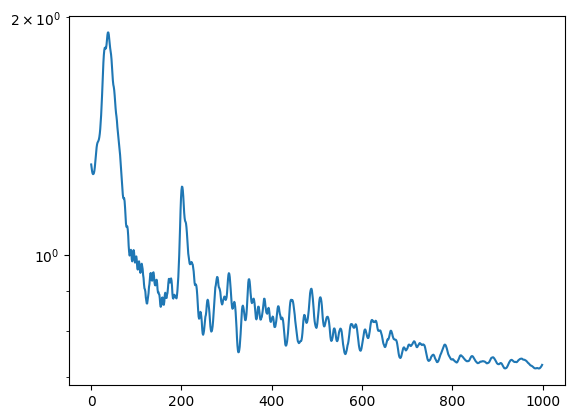

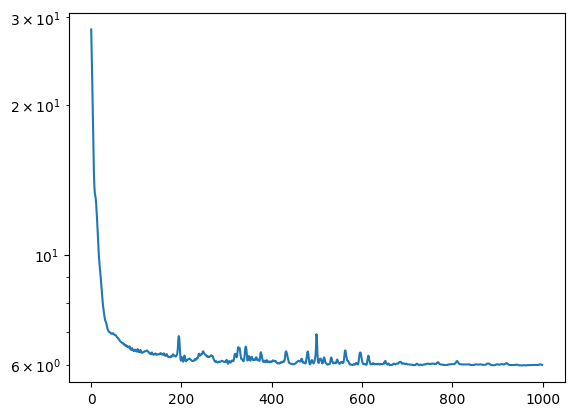

In [116]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    dm_loss, gas_loss = combined_train_step(dm_model, gas_model, dm_optimizer, gas_optimizer)

    dm_losses.append(dm_loss)
    gas_losses.append(gas_loss)
    pbar.set_description(f"dm_loss = {dm_loss:.4f}, gas_loss = {gas_loss:.4f}")
    
fig, ax = plt.subplots()
ax.plot(dm_losses)
ax.set(yscale="log")

fig, ax = plt.subplots()
ax.plot(gas_losses)
ax.set(yscale="log")

### checkpointing

In [88]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim_new_2.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [89]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [90]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:09<00:00,  1.95s/it]


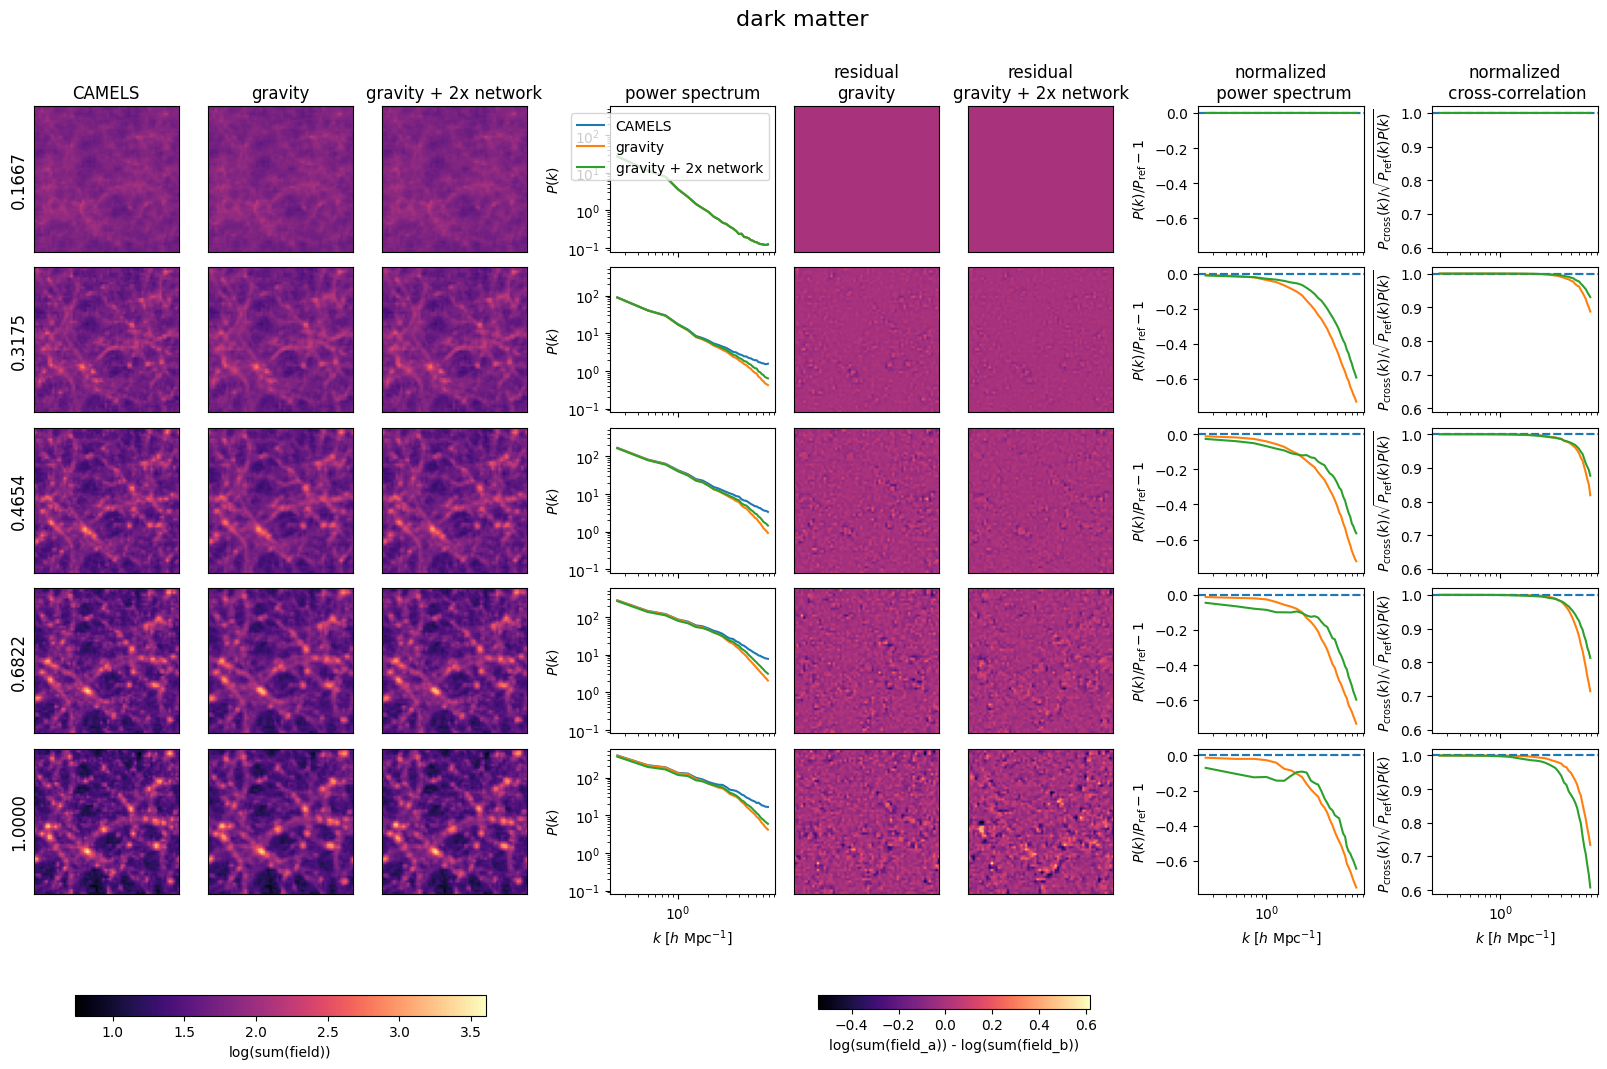

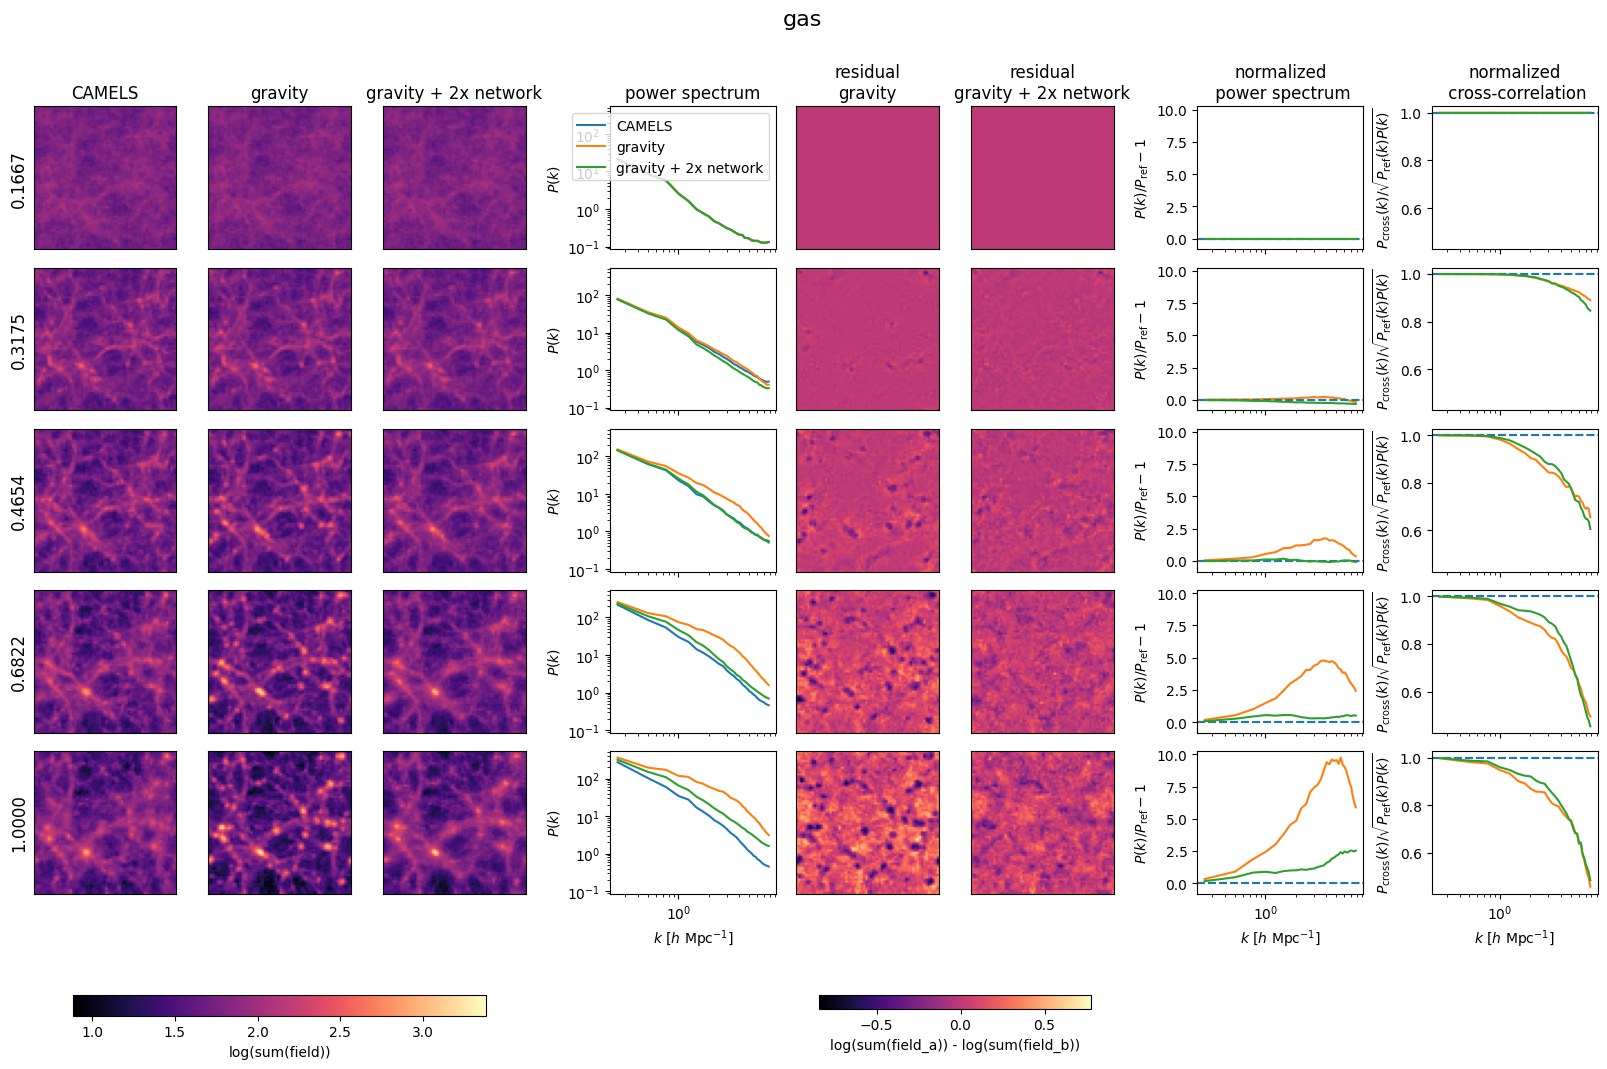

In [117]:
# compare_sims(train_dict, dm_model=dm_model)
# compare_sims(train_dict, gas_model=gas_model)
compare_sims(train_dict, dm_model=dm_model, gas_model=gas_model)

dark matter and gas
dark matter and gas
dark matter and gas
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:11<00:00,  2.23s/it]


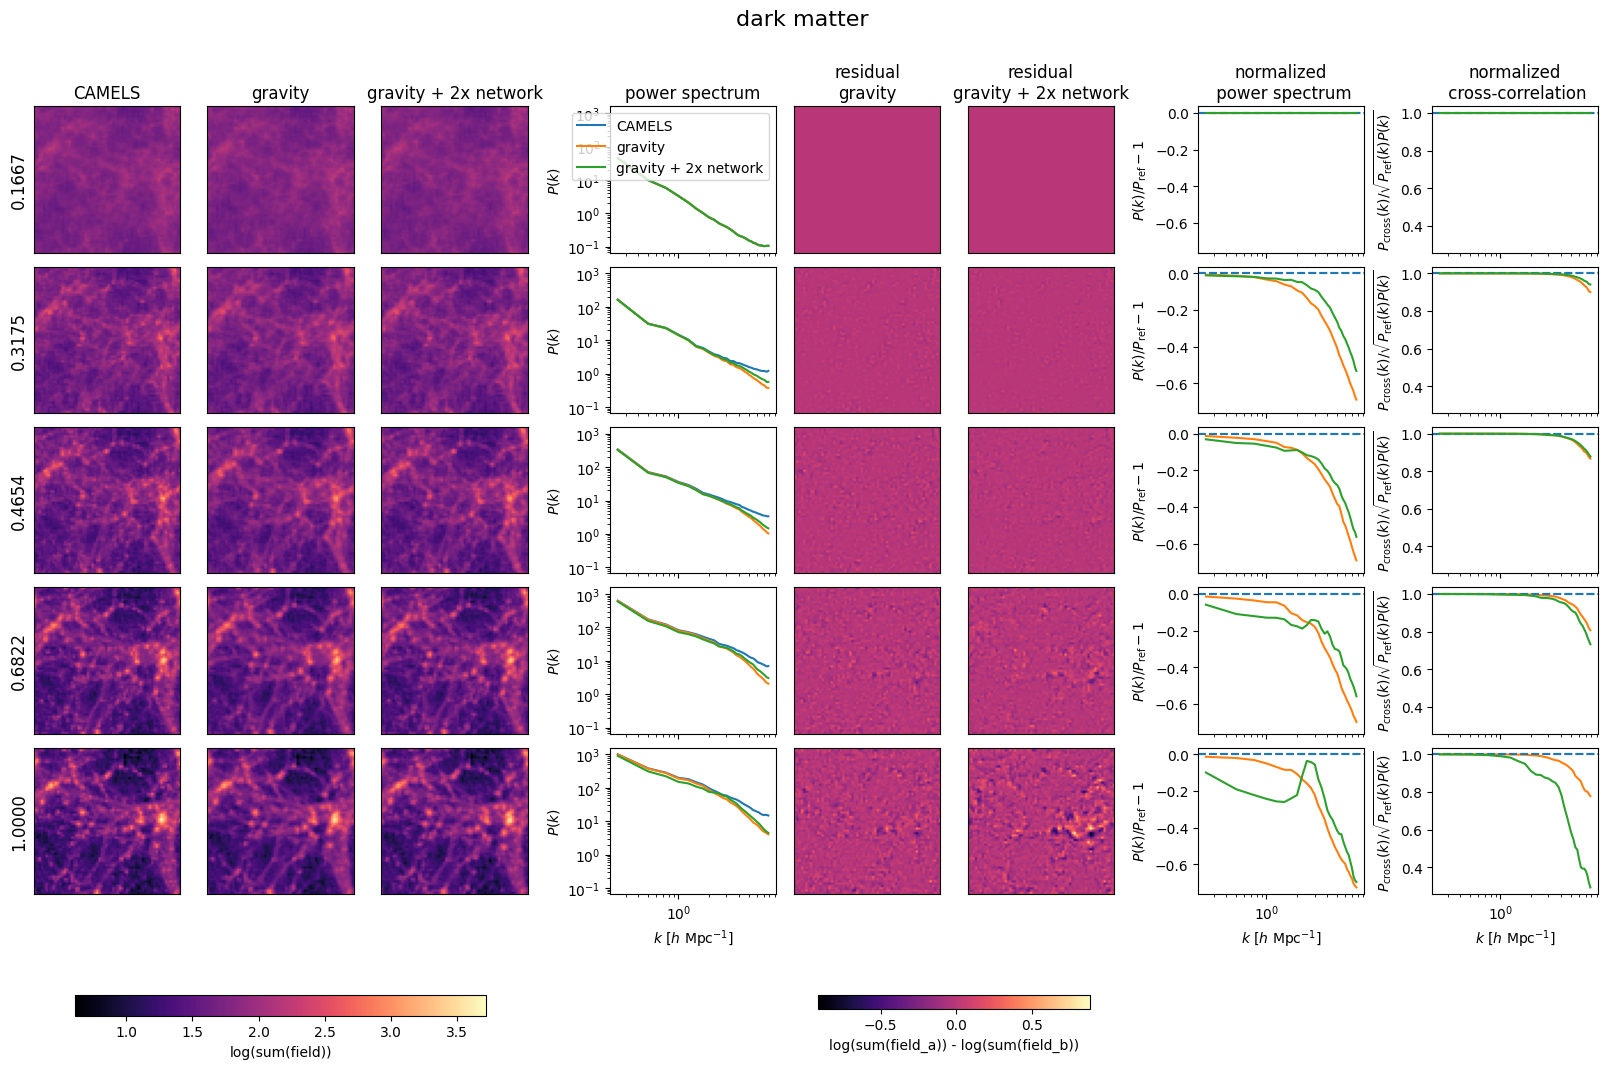

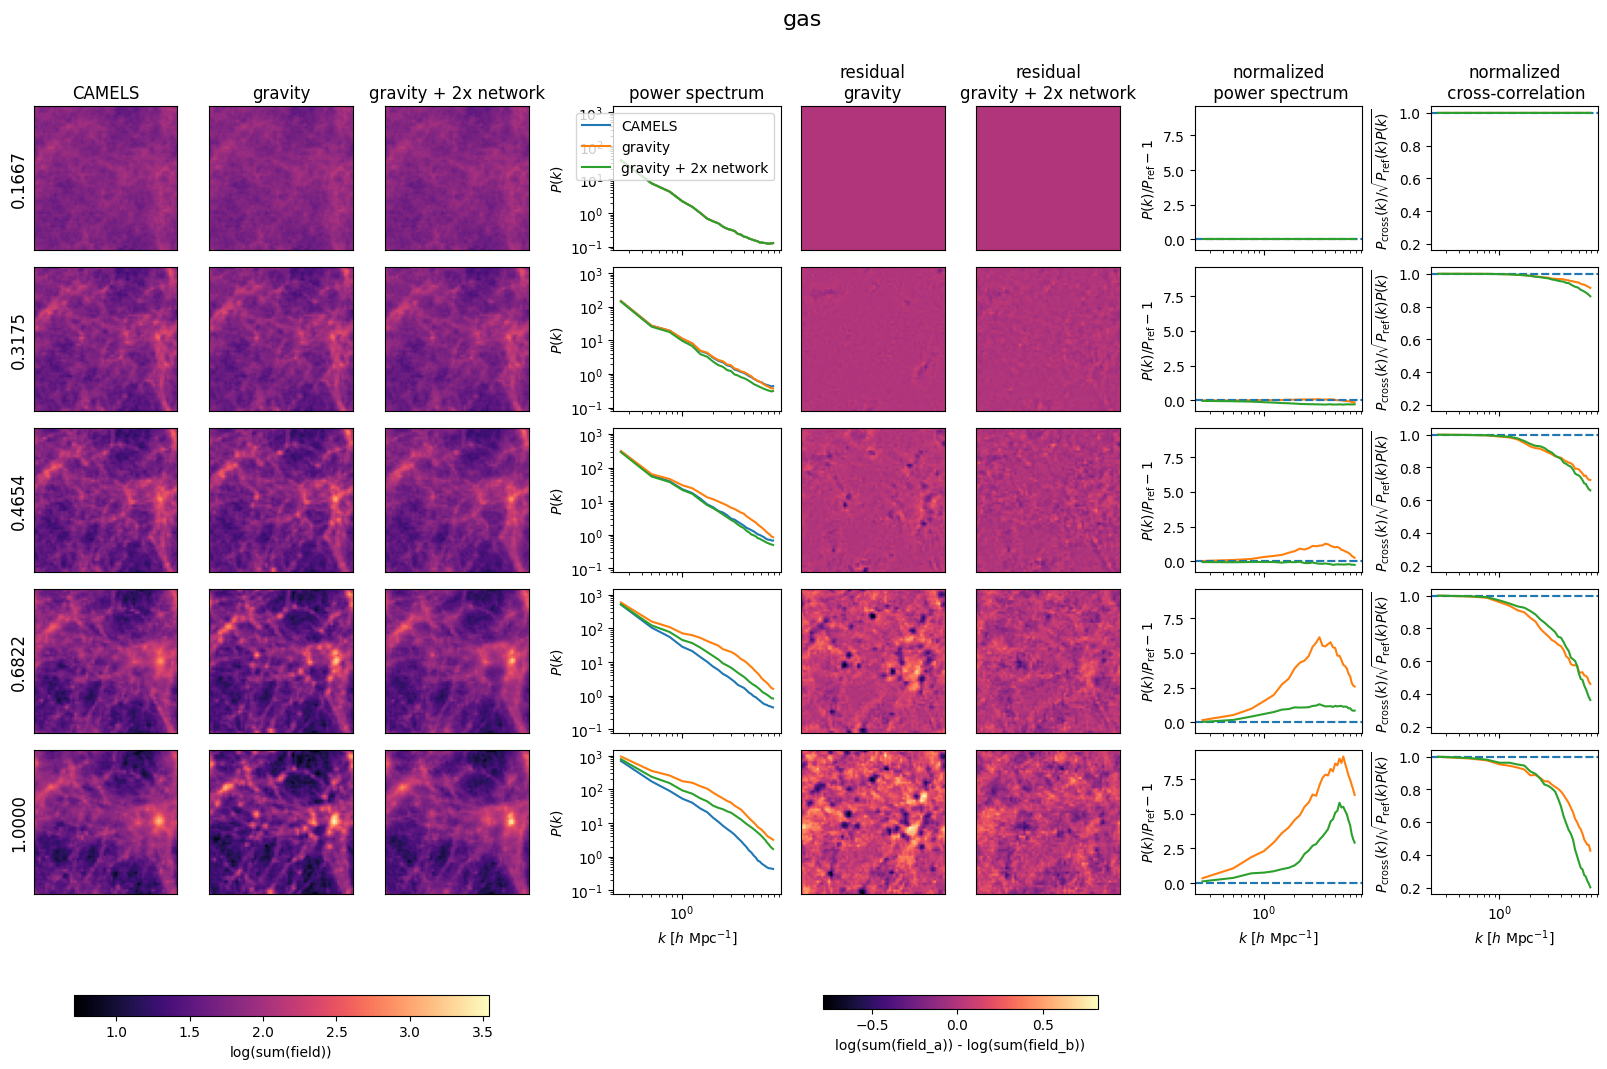

In [118]:
# compare_sims(vali_dict, dm_model=dm_model)
# compare_sims(vali_dict, gas_model=gas_model)
compare_sims(vali_dict, dm_model=dm_model, gas_model=gas_model)

# trash

In [26]:
pm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, architecture="mlp", gravity_only=True, integrator_type="diffrax")

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels, pm_gas_latents = pm_res.ys
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = pm_res.ys

NameError: name 'model' is not defined

In [ ]:
hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, architecture="mlp", gravity_only=False, integrator_type="diffrax")

hpm_res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels, hpm_gas_latents = hpm_res.ys
hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = hpm_res.ys

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    # scales[::4], 
    jnp.stack([gas_poss, pm_gas_poss, hpm_gas_poss], axis=0), 
    # jnp.stack([gas_poss[::4], pm_gas_poss[::4], hpm_gas_poss[::4]], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)